# Foodpanda Customer Segmentation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("E:\\Deep Learning\\Foodpanda\\dataset\\Foodpanda.csv")

date_cols = ["signup_date", "order_date", "last_order_date", "rating_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

text_cols = ["customer_id", "gender", "age", "city", "order_id",
             "restaurant_name", "dish_name", "category",
             "payment_method", "churned", "delivery_status"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["rating_status"] = np.where(df["rating"].isna(), "Not Rated", "Rated")
df["order_value"] = df["quantity"] * df["price"]
df = df.rename(columns={"age": "age_group"})

reference_date = df["last_order_date"].max()
df["tenure_days"] = (reference_date - df["signup_date"]).dt.days
df["recency_days"] = (reference_date - df["last_order_date"]).dt.days
df["order_month"] = df["order_date"].dt.month
df["order_year"] = df["order_date"].dt.year
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.day_name()

print("Shape:", df.shape)
df.head()

Shape: (6000, 28)


,customer_id,gender,age_group,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,rating_date,delivery_status,rating_status,order_value,tenure_days,recency_days,order_month,order_year,order_day,order_weekday
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,...,2024-10-14,Cancelled,Not Rated,7391.35,585,33,8,2023,23,Wednesday
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,...,2025-08-21,Delayed,Rated,2868.12,410,269,8,2023,23,Wednesday
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,2024-09-19,Delayed,Rated,1765.02,62,103,8,2023,23,Wednesday
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,...,2025-06-29,Delayed,Rated,925.20,716,28,8,2023,23,Wednesday
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,...,2025-03-06,Cancelled,Not Rated,1156.69,601,243,8,2023,24,Thursday


In [3]:
customer_seg = df.groupby("customer_id").agg({
    "order_frequency": "mean",
    "loyalty_points": "mean",
    "order_value": "mean",
    "rating": "mean",
    "recency_days": "mean",
    "tenure_days": "mean"
}).reset_index()

customer_seg["rating"] = customer_seg["rating"].fillna(customer_seg["rating"].median())
customer_seg.head()

,customer_id,order_frequency,loyalty_points,order_value,rating,recency_days,tenure_days
0,C1000,26.0,89.0,1210.10,3.0,126.0,433.0
1,C1001,45.0,417.0,1613.60,5.0,208.0,359.0
2,C1002,46.0,489.0,4357.62,4.0,40.0,446.0
3,C1003,16.0,142.0,133.44,3.0,165.0,645.0
4,C1004,40.0,217.0,1044.89,2.0,120.0,331.0


In [4]:
X_seg = customer_seg.drop(columns=["customer_id"])

scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

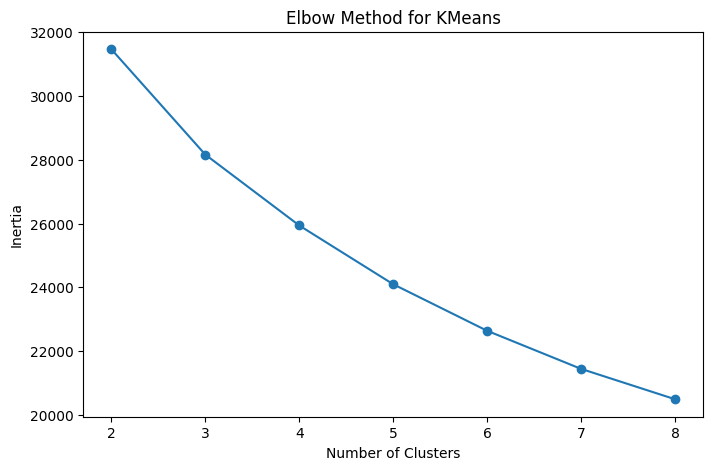

In [5]:
inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_seg_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_seg["cluster"] = kmeans.fit_predict(X_seg_scaled)

score = silhouette_score(X_seg_scaled, customer_seg["cluster"])
print("Silhouette Score:", score)
customer_seg.head()

Silhouette Score: 0.12087094477982005


,customer_id,order_frequency,loyalty_points,order_value,rating,recency_days,tenure_days,cluster
0,C1000,26.0,89.0,1210.10,3.0,126.0,433.0,3
1,C1001,45.0,417.0,1613.60,5.0,208.0,359.0,0
2,C1002,46.0,489.0,4357.62,4.0,40.0,446.0,1
3,C1003,16.0,142.0,133.44,3.0,165.0,645.0,3
4,C1004,40.0,217.0,1044.89,2.0,120.0,331.0,1


In [7]:
cluster_summary = customer_seg.groupby("cluster").mean(numeric_only=True)
cluster_summary

,order_frequency,loyalty_points,order_value,rating,recency_days,tenure_days
cluster,,,,,,
0,25.903743,352.871658,1739.117239,2.946524,282.181150,357.975936
1,24.889571,341.355828,1678.237798,3.022495,77.284935,351.466939
2,26.505863,241.794807,5218.631281,2.935511,176.389447,370.474874
3,24.370591,99.660336,1654.461253,3.093869,186.591427,382.794900


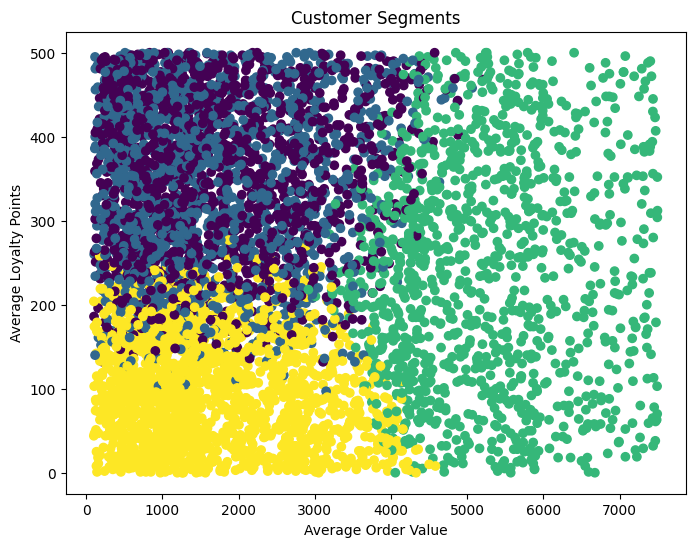

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(customer_seg["order_value"], customer_seg["loyalty_points"], c=customer_seg["cluster"])
plt.title("Customer Segments")
plt.xlabel("Average Order Value")
plt.ylabel("Average Loyalty Points")
plt.show()